In [1]:
import pandas as pd
import os

DATA_PATH = "../data/features/"

files = [f for f in os.listdir(DATA_PATH) if f.endswith(".parquet")]

# Load a few files (not all, to keep it fast)
df_list = [pd.read_parquet(os.path.join(DATA_PATH, f)) for f in files[:5]]

df = pd.concat(df_list, ignore_index=True)

df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,trip_duration,avg_speed,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,hour,day_of_week,congestion_level
0,2016-02-25 17:24:20,2016-02-25 17:27:20,0.70,3.00,14.000000,-73.947250,40.763771,-73.992012,40.735390,17,3,MEDIUM
1,2016-02-25 23:10:50,2016-02-25 23:31:50,5.52,21.00,15.771429,-73.983017,40.750992,-73.988586,40.758839,23,3,MEDIUM
2,2016-02-01 00:00:01,2016-02-01 00:10:52,1.99,10.85,11.004608,-73.992340,40.758202,-73.964355,40.757977,0,0,MEDIUM
3,2016-02-01 00:00:04,2016-02-01 00:05:16,1.50,5.20,17.307692,-73.981453,40.749722,-73.982323,40.763985,0,0,MEDIUM
4,2016-02-01 00:00:05,2016-02-01 00:20:59,5.60,20.90,16.076555,-74.000603,40.729755,-73.951324,40.669834,0,0,MEDIUM


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 494449 entries, 0 to 494448
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   tpep_pickup_datetime   494449 non-null  datetime64[us]
 1   tpep_dropoff_datetime  494449 non-null  datetime64[us]
 2   trip_distance          494449 non-null  float64       
 3   trip_duration          494449 non-null  float64       
 4   avg_speed              494449 non-null  float64       
 5   pickup_longitude       494449 non-null  float64       
 6   pickup_latitude        494449 non-null  float64       
 7   dropoff_longitude      494449 non-null  float64       
 8   dropoff_latitude       494449 non-null  float64       
 9   hour                   494449 non-null  int32         
 10  day_of_week            494449 non-null  int32         
 11  congestion_level       494449 non-null  str           
dtypes: datetime64[us](2), float64(7), int32(2), str(1)
memo

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,trip_duration,avg_speed,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,hour,day_of_week
count,494449,494449,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000,494449.000000
mean,2016-02-17 11:54:37.514019,2016-02-17 12:08:13.340113,2.952818,13.597102,11.713453,-72.762110,40.084611,-72.925031,40.173777,14.589644,2.916210
min,2016-02-01 00:00:00,2016-02-01 00:01:53,0.030000,1.016667,1.004184,-80.738029,0.000000,-74.609085,0.000000,0.000000,0.000000
25%,2016-02-05 13:07:31,2016-02-05 13:32:16,1.000000,6.700000,7.804878,-73.991768,40.736877,-73.991653,40.735500,10.000000,0.000000
50%,2016-02-20 16:03:39,2016-02-20 16:17:32,1.700000,10.950000,10.140845,-73.981415,40.753788,-73.980125,40.754169,15.000000,4.000000
75%,2016-02-22 11:18:12,2016-02-22 11:31:56,3.100000,17.466667,13.628571,-73.965538,40.768963,-73.963814,40.768654,19.000000,5.000000
max,2016-02-29 00:00:31,2016-02-29 00:56:41,71.700000,174.933333,99.574468,0.000000,47.633167,0.000000,42.618668,23.000000,6.000000
std,NaN,NaN,3.664845,10.003716,6.149033,9.383336,5.169418,8.748703,4.819753,5.435678,2.540388


In [3]:
df["congestion_level"].value_counts()

congestion_level
HIGH      240104
MEDIUM    231235
LOW        23110
Name: count, dtype: int64

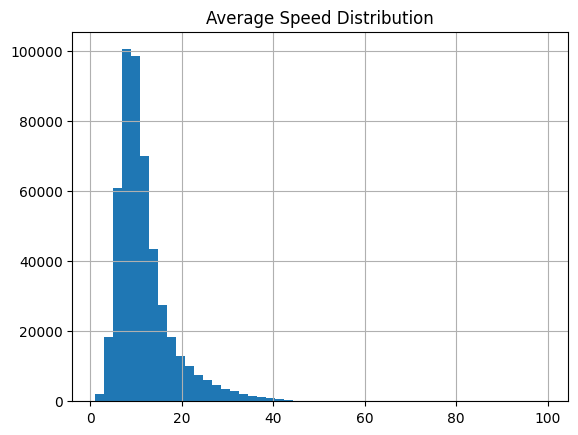

In [4]:
import matplotlib.pyplot as plt

df["avg_speed"].hist(bins=50)
plt.title("Average Speed Distribution")
plt.show()

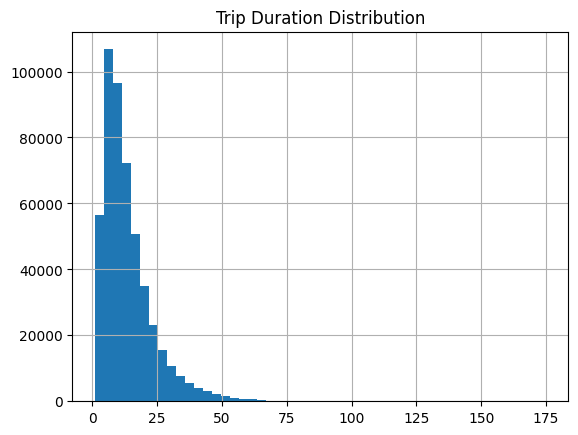

In [5]:
df["trip_duration"].hist(bins=50)
plt.title("Trip Duration Distribution")
plt.show()

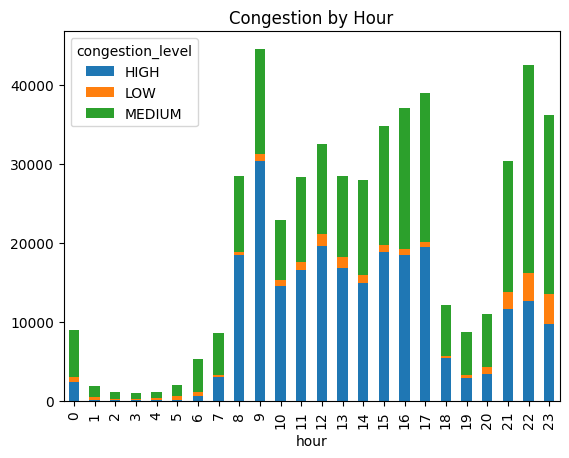

In [6]:
df.groupby("hour")["congestion_level"].value_counts().unstack().plot(kind="bar", stacked=True)
plt.title("Congestion by Hour")
plt.show()

In [7]:
df[["trip_distance", "trip_duration", "avg_speed"]].corr()

,trip_distance,trip_duration,avg_speed
trip_distance,1.000000,0.808374,0.716771
trip_duration,0.808374,1.000000,0.290996
avg_speed,0.716771,0.290996,1.000000
